## SARIMAX Time Series Forecasting with External Factors
## Objective
This notebook demonstrates how to build a classical statistical
time series model (SARIMAX) using external factors such as temperature,
rainfall, holidays, and calendar effects.

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# Load Feature_Engineered Dataset
df=pd.read_csv("feature_engineered_time_series.csv")
df['date']=pd.to_datetime(df['date'])
df=df.set_index('date')
df.head()

,electricity_demand,temperature_celsius,rainfall_mm,is_holiday,lag_1,lag_7,lag_30,rolling_7_mean,rolling_30_mean,day,month,day_of_week,week_of_year,is_weekend
date,,,,,,,,,,,,,,
2019-01-31,429.01,28.88,3.04,0,445.62,430.58,414.34,435.101429,426.843667,31,1,3,5,0
2019-02-01,452.72,33.94,2.47,0,429.01,436.01,399.36,437.488571,428.622333,1,2,4,5,0
2019-02-02,421.28,30.35,6.83,1,452.72,438.60,391.19,435.014286,429.625333,2,2,5,5,1
2019-02-03,443.77,28.41,7.43,1,421.28,411.02,433.55,439.692857,429.966000,3,2,6,5,1
2019-02-04,473.09,32.31,5.02,0,443.77,441.64,428.43,444.185714,431.454667,4,2,0,6,0


Explanation
Using output from Notebook-2
Dataset contains lag, rolling, weather, and calendar features

In [3]:
# Select Target and Exogenous Variables
target = df['electricity_demand']

exog_features = [
    'temperature_celsius',
    'rainfall_mm',
    'is_holiday',
    'is_weekend',
    'rolling_7_mean',
    'rolling_30_mean']

exog = df[exog_features]

What are Exogenous Variables ?
Exogenous variables are external factors that influence the target
but are not part of its past values.

In [6]:
# Train-Test Split ( Time Based )
split_date = '2023-01-01'

Y_train = target[target.index < split_date]
Y_test  = target[target.index >= split_date]

exog_train = exog[exog.index < split_date]
exog_test  = exog[exog.index >= split_date]

In [10]:
# To Find Auto ARIMA
from pmdarima import auto_arima
auto_arima(Y_train,seasonal=True,m=7)

ARIMA(order=(0, 1, 1), scoring_args={}, seasonal_order=(0, 0, 2, 7),
      suppress_warnings=True, with_intercept=False)

In [11]:
# Build SARIMAX Model
model = SARIMAX(
    Y_train,
    exog=exog_train,
    order=(0, 1, 1),
    seasonal_order=(0, 0, 2, 7),
    enforce_stationarity=False,
    enforce_invertibility=False)

C:\Users\Chinnarajan M\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Chinnarajan M\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Parameter     Meaning

(0,1,1)       AR, Differencing, MA

(0,0,2,7)     Weekly seasonality

exog          External variables


In [12]:
# Train the Model
sarimax_result = model.fit(disp=False)
sarimax_result.summary()

C:\Users\Chinnarajan M\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                       SARIMAX Results                                        
==============================================================================================
Dep. Variable:                     electricity_demand   No. Observations:                 1431
Model:             SARIMAX(0, 1, 1)x(0, 0, [1, 2], 7)   Log Likelihood               -5861.999
Date:                                Tue, 24 Feb 2026   AIC                          11743.999
Time:                                        19:55:24   BIC                          11796.541
Sample:                                    01-31-2019   HQIC                         11763.630
                                         - 12-31-2022                                         
Covariance Type:                                  opg                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
temperature_celsius     3.9873      0.185     21.560      0.000       3.625       4.350
rainfall_mm            -1.7904      0.098    -18.273      0.000      -1.982      -1.598
is_holiday              8.2070      0.483     16.979      0.000       7.260       9.154
is_weekend              8.2070      0.483     16.979      0.000       7.260       9.154
rolling_7_mean          0.4764      0.051      9.293      0.000       0.376       0.577
rolling_30_mean        -0.2432      0.047     -5.198      0.000      -0.335      -0.151
ma.L1                  -1.0001      0.065    -15.286      0.000      -1.128      -0.872
ma.S.L7                 0.0356      0.028      1.286      0.198      -0.019       0.090
ma.S.L14                0.0246      0.026      0.934      0.350      -0.027       0.076
sigma2                228.5195     17.224     13.267      0.000     194.761     262.278
===================================================================================
Ljung-Box (L1) (Q):                   6.62   Jarque-Bera (JB):                 0.96
Prob(Q):                              0.01   Prob(JB):                         0.62
Heteroskedasticity (H):               1.09   Skew:                            -0.06
Prob(H) (two-sided):                  0.36   Kurtosis:                         3.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 4.13e+19. Standard errors may be unstable.
"""

SARIMAX combines ARIMA with regression on external variables.

In [13]:
# Forecast Using External Factors
Y_pred = sarimax_result.predict(start=Y_test.index[0],end=Y_test.index[-1],exog=exog_test)

In [14]:
Y_pred

2023-01-01    422.652942
2023-01-02    411.736342
2023-01-03    404.664233
2023-01-04    413.348221
2023-01-05    418.045756
                 ...    
2023-12-27    402.577355
2023-12-28    412.815010
2023-12-29    409.334800
2023-12-30    436.200019
2023-12-31    410.205236
Freq: D, Name: predicted_mean, Length: 365, dtype: float64

In [15]:
# Evaluate Model Performance
mae = mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))

print("SARIMAX MAE:", mae)
print("SARIMAX RMSE:", rmse)

SARIMAX MAE: 11.143196015570869
SARIMAX RMSE: 14.16323129615055


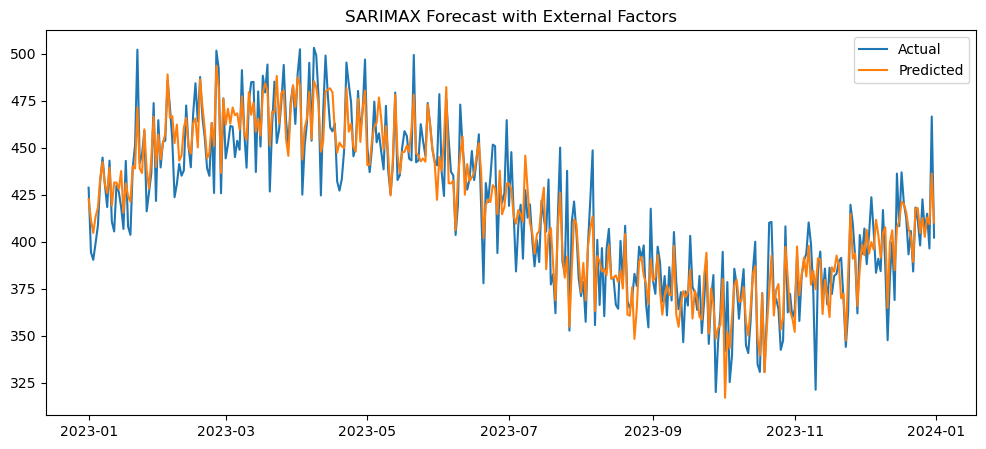

In [16]:
# Plot Actual vs Predicted
plt.figure(figsize=(12,5))
plt.plot(Y_test.index, Y_test, label='Actual')
plt.plot(Y_test.index, Y_pred, label='Predicted')
plt.title("SARIMAX Forecast with External Factors")
plt.legend()
plt.show()

Observation
SARIMAX handles seasonality well
External variables improve forecast accuracy

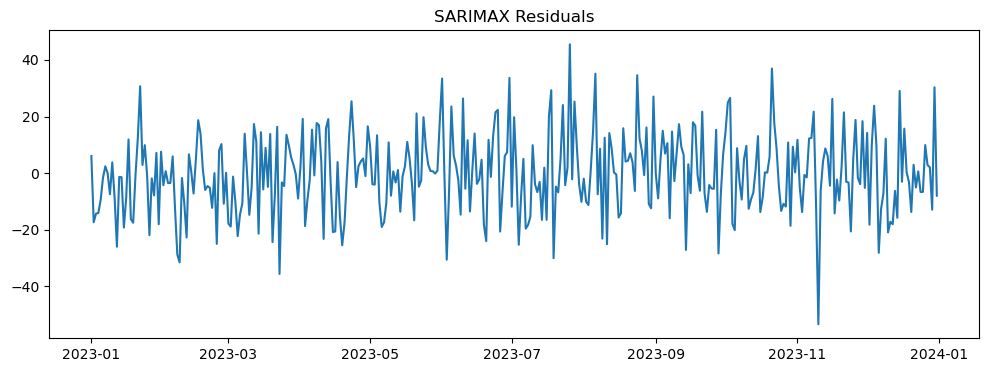

In [17]:
# Residual Analysis
residuals = Y_test - Y_pred
plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title("SARIMAX Residuals")
plt.show()

Why Residual Analysis ?
Residuals should look like white noise for a good model.

In [18]:
# Forecast Future Values 
future_steps = 30
future_exog = exog_test.iloc[:future_steps]
future_forecast = sarimax_result.forecast(
    steps=future_steps,
    exog=future_exog)

future_forecast

2023-01-01    422.652942
2023-01-02    411.736342
2023-01-03    404.664233
2023-01-04    413.348221
2023-01-05    418.045756
2023-01-06    433.764156
2023-01-07    442.316255
2023-01-08    430.468889
2023-01-09    425.858299
2023-01-10    439.305080
2023-01-11    419.217405
2023-01-12    431.469600
2023-01-13    431.452181
2023-01-14    427.928495
2023-01-15    437.600652
2023-01-16    415.439957
2023-01-17    431.080040
2023-01-18    424.268845
2023-01-19    421.194166
2023-01-20    440.329895
2023-01-21    438.906313
2023-01-22    471.383531
2023-01-23    438.878662
2023-01-24    436.521301
2023-01-25    459.741406
2023-01-26    438.064677
2023-01-27    428.308429
2023-01-28    444.266533
2023-01-29    466.524299
2023-01-30    439.726414
Freq: D, Name: predicted_mean, dtype: float64

# Key Learnings from (Notebook - 4)
1. SARIMAX supports external (exogenous) variables
2. Seasonality improves long-term forecasting
3. Statistical models are highly interpretable
4. Ideal for interviews and real-world forecasting